In [1]:
%pip install Faker

Note: you may need to restart the kernel to use updated packages.


In [2]:
from faker import Faker

In [13]:
import pandas as pd

In [8]:
import random

In [3]:
#Creamos una instancia de Faker 
fake = Faker("es_MX")

In [35]:
#Generamos significativos : 100 registros
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100,50000),
        "plataforma": random.choice(
            ["TikTok","Instagram","YouTube"]
    )
})

In [36]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Ing. Guillermo Paredes,julio-cesarangulo@example.com,48,1535,YouTube
1,2,Raquel Aguilera Alarcón,silvia06@example.net,33,46156,YouTube
2,3,Srita. Antonia Almonte,dmatos@example.com,34,30653,YouTube
3,4,Berta Rolón,rodartereynaldo@example.net,39,18167,Instagram
4,5,Srita. Karla Carbajal,fanaya@example.net,48,40261,TikTok


In [16]:
#Exploración de DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [17]:
#Estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.000000,100.000000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Óliver Alba Salas,cornelio72@example.com,NaN,NaN,TikTok
freq,NaN,1,1,NaN,NaN,34
mean,50.500000,NaN,NaN,39.630000,22532.970000,NaN
std,29.011492,NaN,NaN,13.298177,14091.462926,NaN
min,1.000000,NaN,NaN,18.000000,574.000000,NaN
25%,25.750000,NaN,NaN,27.750000,10860.750000,NaN
50%,50.500000,NaN,NaN,39.000000,22154.500000,NaN
75%,75.250000,NaN,NaN,52.000000,34401.750000,NaN


In [18]:
import seaborn as sns

In [19]:
import matplotlib.pyplot as plt

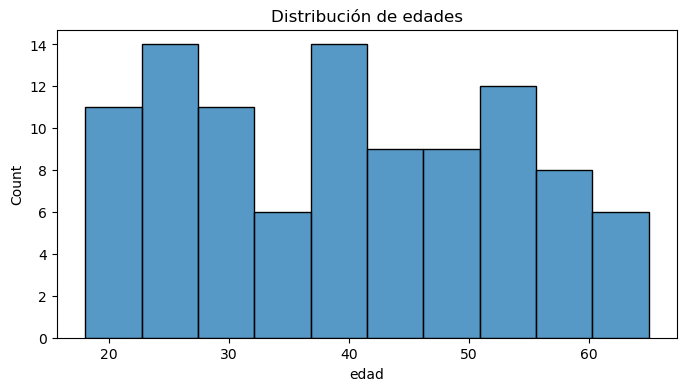

In [20]:
# Distribución de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

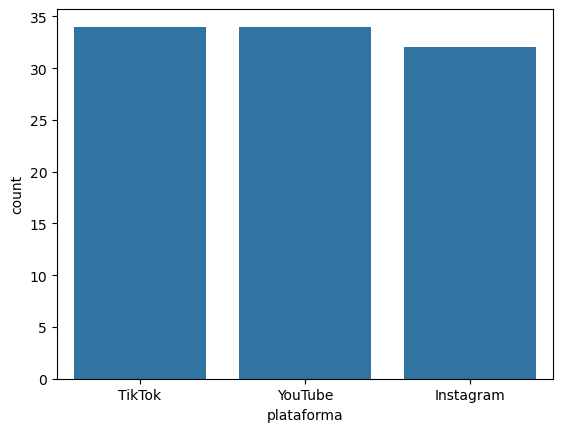

In [21]:
#Usuarios po plataforma 
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [22]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [23]:
#Le colocamos valoes nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"] = None

In [24]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [28]:
#Edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [29]:
df_sucio.describe()["edad"]

count    100.000000
mean      37.420000
std       16.739345
min      -10.000000
25%       26.750000
50%       39.000000
75%       49.250000
max       65.000000
Name: edad, dtype: float64

In [30]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
     df_sucio.loc[i,"seguidores"] = 5000000

In [31]:
df_sucio.describe()["seguidores"]

count    1.000000e+02
mean     2.711770e+05
std      1.090421e+06
min      5.740000e+02
25%      1.086075e+04
50%      2.278550e+04
75%      3.749475e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [32]:
#Generamos correos invalidos 
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "correo" ] = "correo_invalido"

In [37]:
df_sucio.describe(include=["object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Óliver Alba Salas,correo_invalido,TikTok
freq,1,5,34


In [38]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [43]:
pd.set_option('display.float_format',lambda x:'%.2f' % x)

In [44]:
#Estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.00,95,100,100.00,100.00,100
unique,NaN,95,96,NaN,NaN,3
top,NaN,Óliver Alba Salas,correo_invalido,NaN,NaN,TikTok
freq,NaN,1,5,NaN,NaN,34
mean,50.50,NaN,NaN,37.42,271177.04,NaN
std,29.01,NaN,NaN,16.74,1090421.46,NaN
min,1.00,NaN,NaN,-10.00,574.00,NaN
25%,25.75,NaN,NaN,26.75,10860.75,NaN
50%,50.50,NaN,NaN,39.00,22785.50,NaN
75%,75.25,NaN,NaN,49.25,37494.75,NaN
